# Tutorial 11 -- Qubit T1 Relaxation

Simulate energy relaxation with `NoiseSpec(t1=...)`, fit the decay, and recover the relaxation time from the final excited-state population.

**Prerequisites.** Tutorial 04 is a helpful precursor.


## 1. Goal

We will start in `|e>` and measure how the excited-state population decays under a Lindblad `T1` model.


## 2. Physical Background

`T1` is the energy-relaxation time. In a simple two-level model with no drive and no thermal repopulation, the excited-state population decays exponentially as `exp(-t / T1)`.


## 3. Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    NoiseSpec,
    Pulse,
    SequenceCompiler,
    SimulationConfig,
    simulate_sequence,
)
from tutorials.tutorial_support import (
    GHz,
    final_expectation,
    fit_exponential_decay,
    ns,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 4. Simulation Parameters


In [2]:
t1_true = 18.0 * us
delays_us = np.linspace(0.0, 40.0, 33)
dt = 20.0 * ns


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.2),
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=1,
    n_tr=2,
)
frame = FrameSpec(omega_q_frame=model.omega_q)
initial_state = model.basis_state(1, 0)
noise = NoiseSpec(t1=t1_true)


## 6. Pulse / Sequence Construction


In [4]:
delays_s = delays_us * us
responses = []
for delay_s in delays_s:
    compiled = SequenceCompiler(dt=dt).compile([], t_end=float(max(delay_s, dt)))
    result = simulate_sequence(
        model,
        compiled,
        initial_state,
        {},
        config=SimulationConfig(frame=frame, max_step=dt),
        noise=noise,
    )
    responses.append(final_expectation(result, "P_e"))
responses = np.asarray(responses, dtype=float)


## 7. Running the Simulation


In [5]:
theory_responses = t1_relaxation_population(delays_s, t1_true)
fit = fit_exponential_decay(delays_s, responses, parameter_name="t1")
print(f"True T1 = {t1_true / us:.3f} us")
print(f"Fitted T1 = {fit.parameters['t1'] / us:.3f} us")
print(f"Maximum |simulation - exp(-t/T1)| = {np.max(np.abs(responses - theory_responses)):.3e}")


True T1 = 18.000 us
Fitted T1 = 18.024 us
Maximum |simulation - exp(-t/T1)| = 1.110e-03


## 8. Visualizing the Results


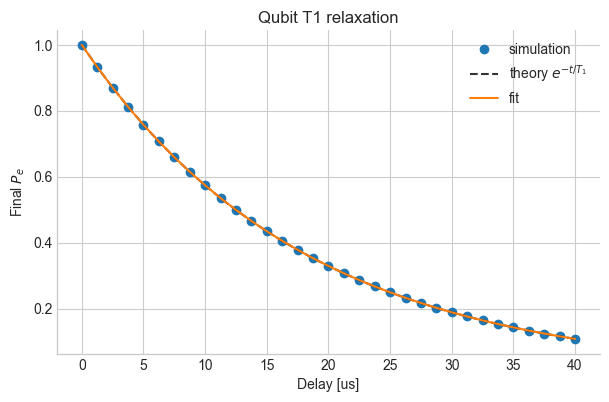

In [6]:
fig, ax = plt.subplots()
ax.plot(delays_us, responses, "o", label="simulation")
ax.plot(delays_us, theory_responses, "--", color="black", alpha=0.8, label=r"theory $e^{-t/T_1}$")
ax.plot(delays_us, fit.model_y, "-", label="fit")
ax.set_xlabel("Delay [us]")
ax.set_ylabel(r"Final $P_e$")
ax.set_title("Qubit T1 relaxation")
ax.legend()
plt.show()


## 9. Physical Interpretation

This is the cleanest calibration-style notebook in the suite because the model prediction is directly exponential. The fitted `T1` becomes part of the open-system parameter set used in later Ramsey, echo, and readout examples.


## 10. Exercises / Next Steps

- Add a nonzero cavity mode with finite `chi` and verify that the relaxation fit is still dominated by the same `T1` model when the cavity stays in vacuum.
- Explore what happens when `t1` becomes comparable to the pulse durations used in Tutorials 09 and 10.
- Continue to Tutorial 12 for dephasing-sensitive Ramsey fringes.
